## Unit 8. Neural Networks and Deep Learning

Fashion classification using images

### 8.1 Fashion Classification

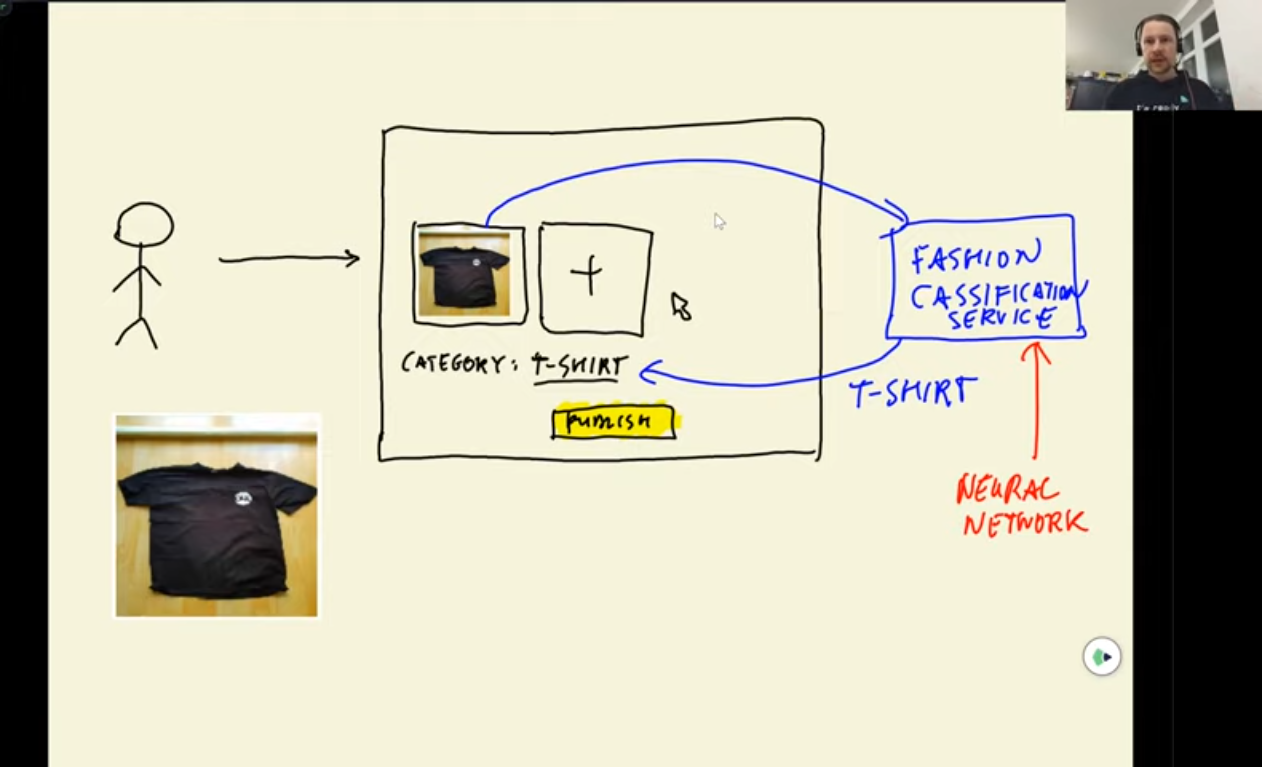

Theory:
https://cs231n.github.io/

### 8.2 TensorFlow and Keras

- Installing TensorFlow
- Loading images

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
import tensorflow as tf
from tensorflow import keras

2025-11-26 00:31:10.392622: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-26 00:31:10.392887: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-26 00:31:10.428115: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-26 00:31:11.246488: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

In [3]:
from tensorflow.keras.preprocessing.image import load_img

In [4]:
path = "./clothing-dataset-small/train/t-shirt"
name = "5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg"
fullname = f'{path}/{name}'
fullname

'./clothing-dataset-small/train/t-shirt/5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg'

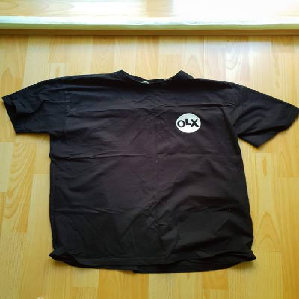

In [5]:
img = load_img(fullname, target_size=(299, 299))
img

Why to specify the size
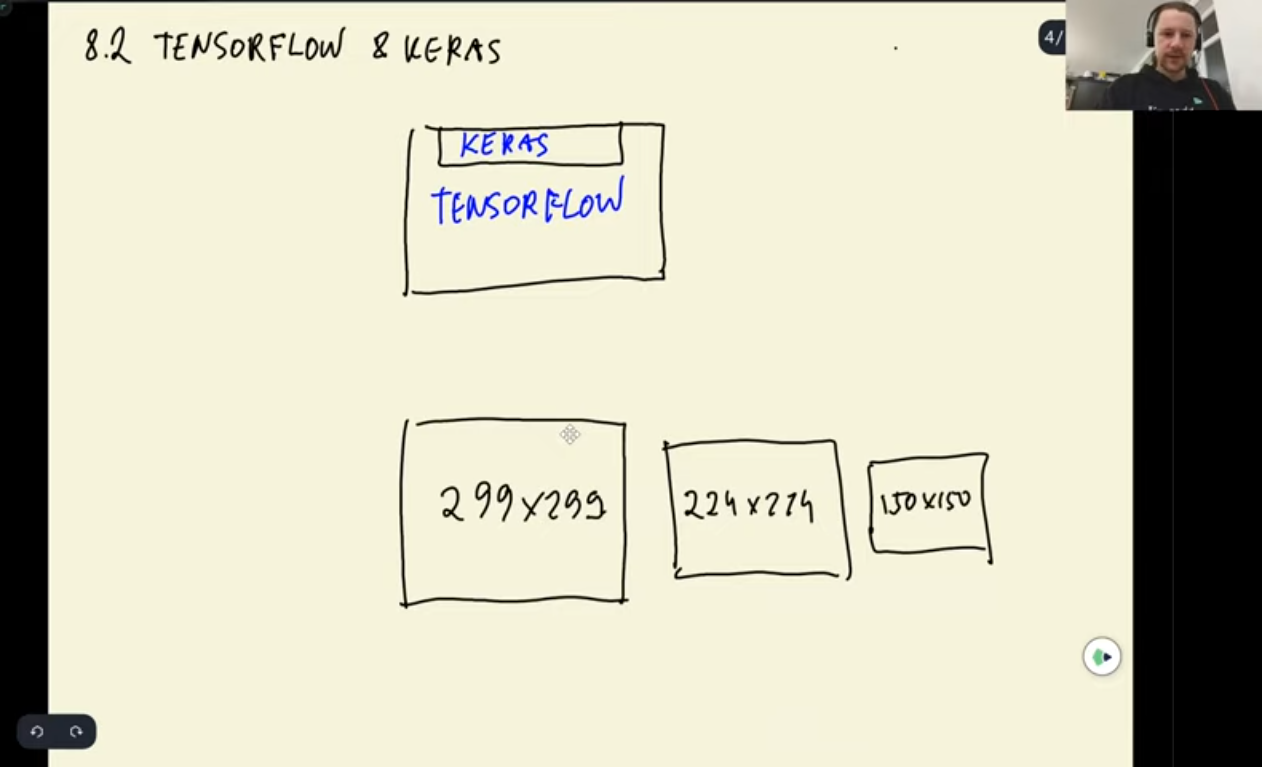

In [6]:
# Translating the image into a numpy array
x = np.array(img)
x.shape

(299, 299, 3)

In [7]:
x

array([[[179, 171,  99],
        [179, 171,  99],
        [181, 173, 101],
        ...,
        [251, 253, 248],
        [251, 253, 248],
        [251, 254, 247]],

       [[188, 179, 112],
        [187, 178, 111],
        [186, 177, 108],
        ...,
        [251, 252, 247],
        [251, 252, 247],
        [251, 252, 246]],

       [[199, 189, 127],
        [200, 190, 128],
        [200, 191, 126],
        ...,
        [250, 251, 245],
        [250, 251, 245],
        [250, 251, 245]],

       ...,

       [[165, 151,  76],
        [173, 159,  84],
        [171, 157,  82],
        ...,
        [183, 135,  25],
        [181, 133,  22],
        [183, 135,  24]],

       [[165, 151,  76],
        [173, 159,  84],
        [171, 157,  82],
        ...,
        [182, 134,  23],
        [180, 132,  21],
        [182, 134,  23]],

       [[165, 151,  76],
        [173, 159,  84],
        [171, 157,  82],
        ...,
        [181, 133,  22],
        [179, 131,  20],
        [182, 134,  23]]

### 8.3 Pre-trained convolutional neural networks

Imagenet datasets: image-net.org

Pre-trained models: keras.io/api/applications

In [8]:
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions

In [9]:
model = Xception(weights='imagenet', input_shape=(299,299,3))

E0000 00:00:1764088273.640371    9585 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1764088273.646269    9585 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [10]:
# Putting an image into an array of images because the model expects a batch of images
X = np.array([x])
X.shape

(1, 299, 299, 3)

In [11]:
# The image should be preprocessed to make sense
X = preprocess_input(X)

In [12]:
model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step


array([[3.23712302e-04, 1.57383896e-04, 2.13493287e-04, 1.52370572e-04,
        2.47626333e-04, 3.05035966e-04, 3.20592400e-04, 1.47499362e-04,
        2.03621923e-04, 1.49272484e-04, 1.95663175e-04, 2.10137499e-04,
        7.59265313e-05, 1.13972274e-04, 1.62683617e-04, 2.04638694e-04,
        1.97416230e-04, 1.44288933e-04, 1.40217555e-04, 1.73686043e-04,
        7.46690610e-04, 2.56966887e-04, 2.66808958e-04, 2.96514481e-04,
        3.73602641e-04, 2.77404353e-04, 2.16570945e-04, 2.27270240e-04,
        3.80813086e-04, 1.72166023e-04, 3.05401161e-04, 1.96431400e-04,
        3.92115151e-04, 4.78071859e-04, 2.91751436e-04, 3.25693487e-04,
        1.47395302e-04, 1.62362150e-04, 2.12710656e-04, 1.34028320e-04,
        2.40070614e-04, 6.75212184e-04, 2.54943705e-04, 1.44478807e-04,
        4.12821537e-04, 2.04408745e-04, 3.02958302e-04, 1.49339685e-04,
        1.99653805e-04, 2.27005963e-04, 2.93729419e-04, 2.27444776e-04,
        6.37644727e-04, 7.82616087e-04, 2.49557430e-04, 4.052708

In [13]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


In [14]:
# Deoding predictions for human-readable format
decode_predictions(pred)

[[('n03595614', 'jersey', np.float32(0.6819629)),
  ('n02916936', 'bulletproof_vest', np.float32(0.03814003)),
  ('n04370456', 'sweatshirt', np.float32(0.0343248)),
  ('n03710637', 'maillot', np.float32(0.011354244)),
  ('n04525038', 'velvet', np.float32(0.0018453615))]]

### 8.4 Convolutional neural networks

- Types of layers: convolutional and dense
- Convolutional layers and filters
- Dense layers

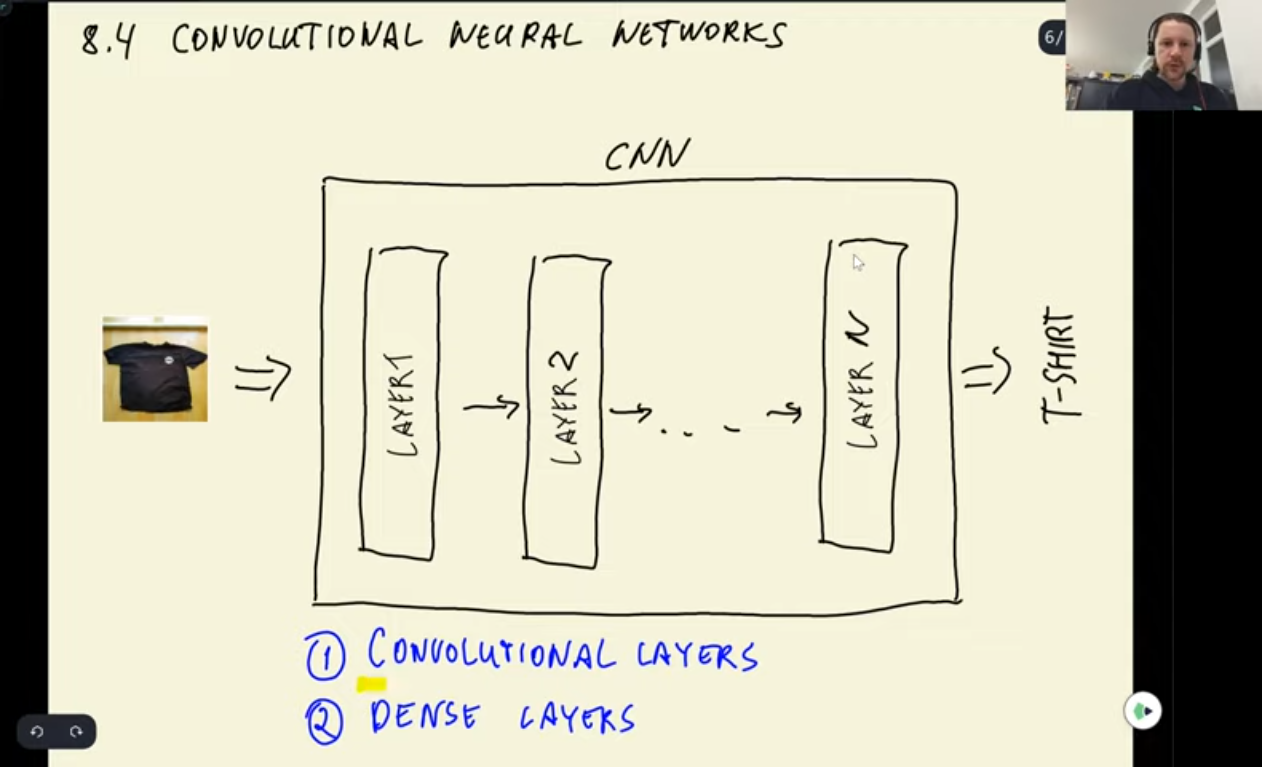

Filters - small images that contain simple shapes. We calculate similarity of the filter with particular part of the image
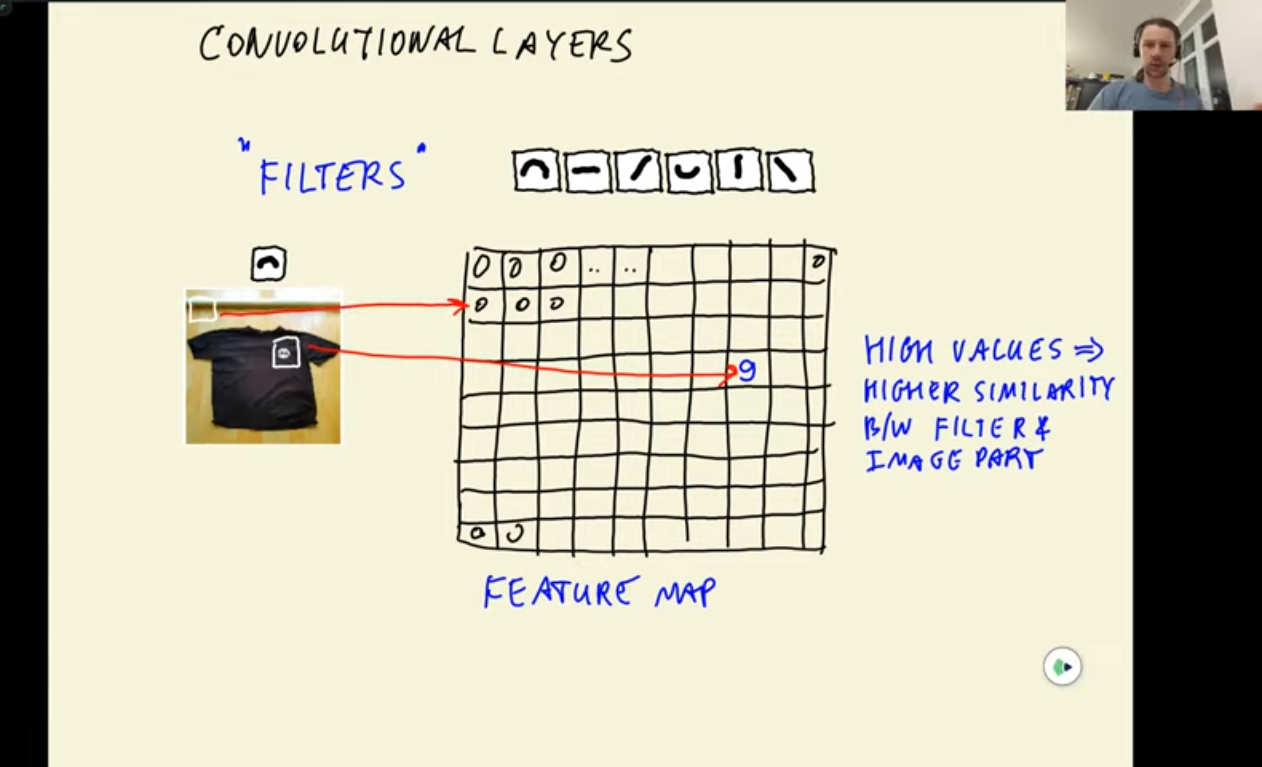

One feature map per filter
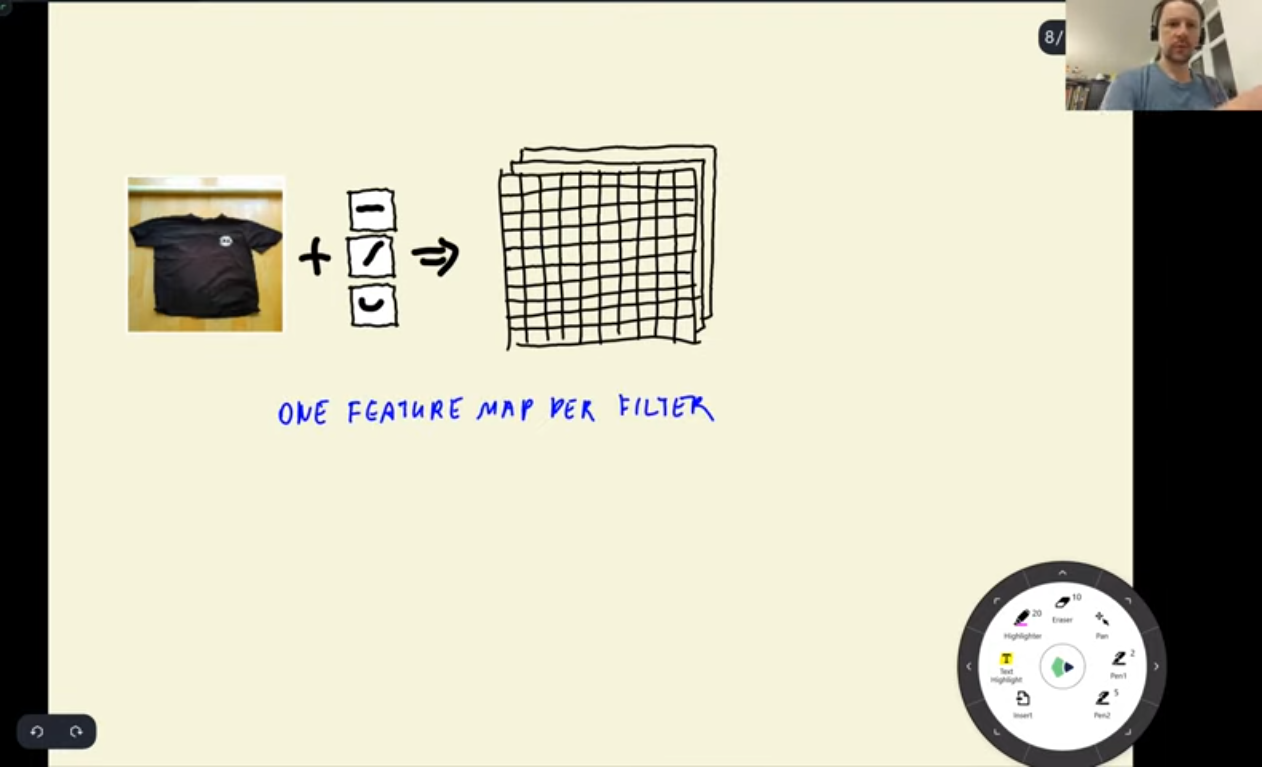

Each new level introduces more complex filters that often combine simpler filters
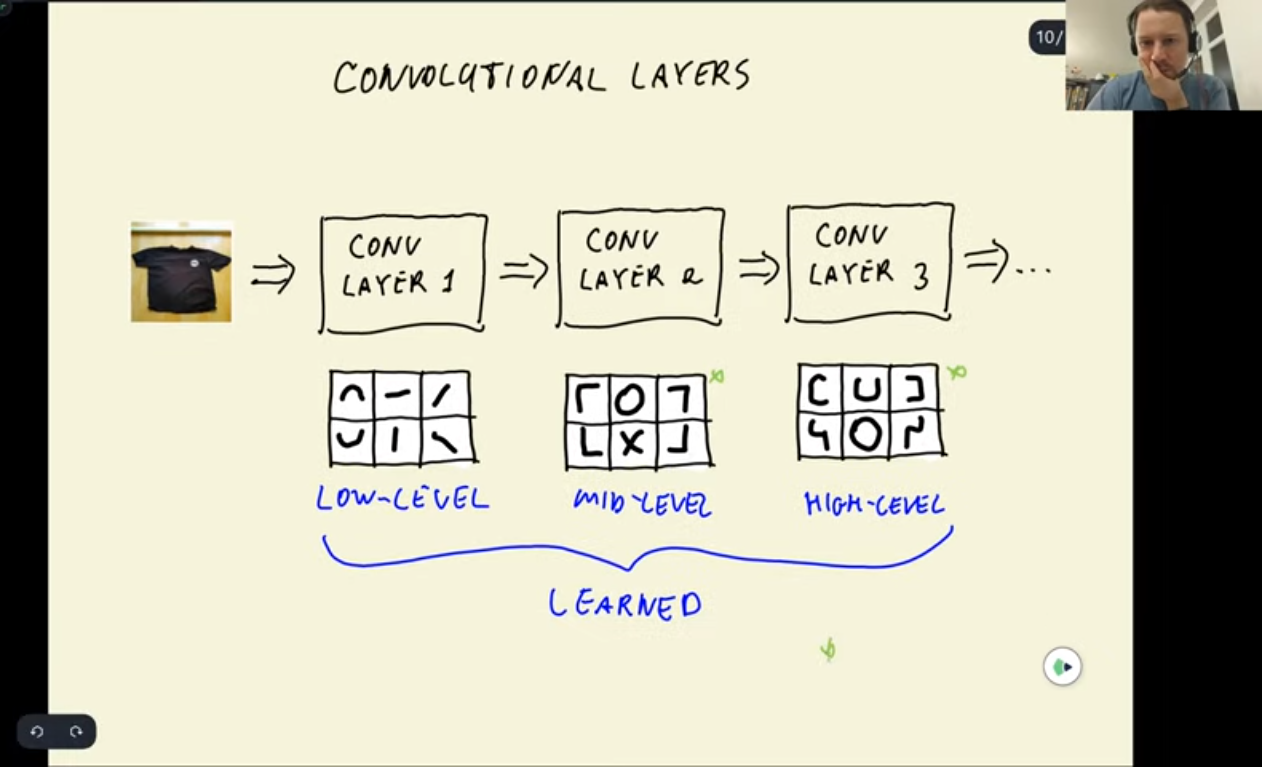

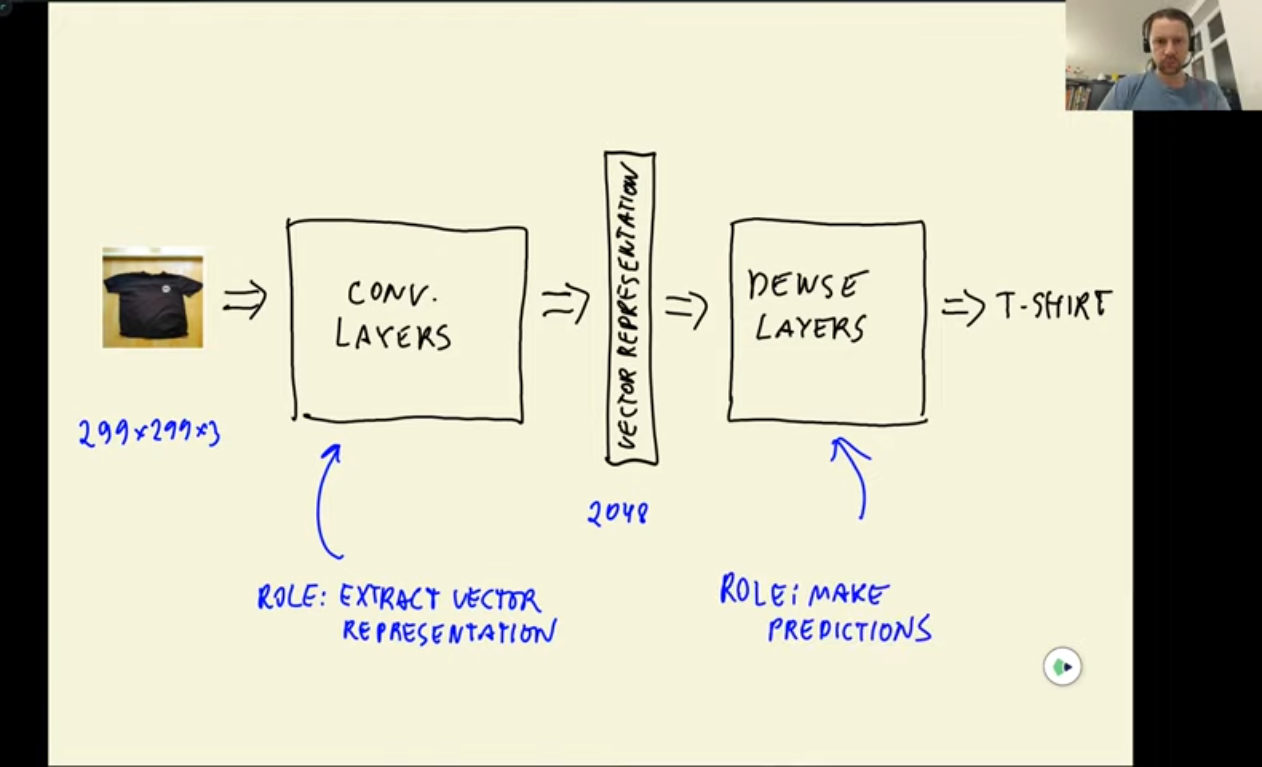

Dense layer is just matrix multiplication
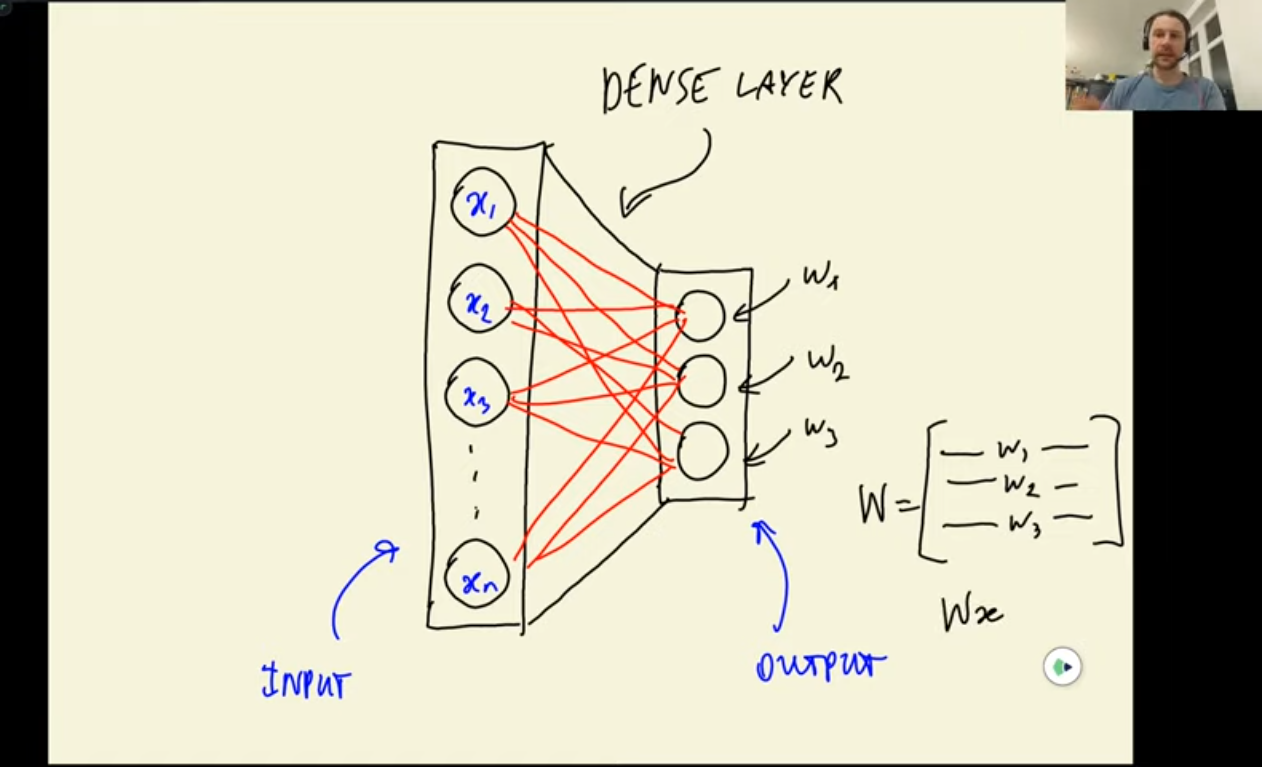

### 8.5 Transfer learning